In [ ]:
# Cell 1 — Install
!pip install transformers torch torchvision pillow datasets huggingface_hub -q

In [ ]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

import os
SAVE_DIR = "/content/drive/MyDrive/MuseumCaption"
M2_DIR   = f"{SAVE_DIR}/milestone2_v2"
os.makedirs(M2_DIR, exist_ok=True)
print(f"M1 cache : {SAVE_DIR}")
print(f"M2 output: {M2_DIR}")

Mounted at /content/drive
M1 cache : /content/drive/MyDrive/MuseumCaption
M2 output: /content/drive/MyDrive/MuseumCaption/milestone2_v2


In [ ]:
# Cell 3 — Imports
import torch
import pickle
import re
import textwrap
import matplotlib.pyplot as plt
from PIL import Image
from transformers import (
    CLIPProcessor, CLIPModel,
    GPT2Tokenizer, GPT2LMHeadModel,
    BlipProcessor, BlipForConditionalGeneration
)
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim


In [ ]:
# Cell 4 — Device
assert torch.cuda.is_available(), "Go to Runtime > Change runtime type > GPU"
device = "cuda"
print(f"GPU: {torch.cuda.get_device_name(0)}")

GPU: NVIDIA A100-SXM4-40GB


In [ ]:
# Cell 5 — Load CLIP from M1 Cache
CLIP_PATH      = f"{SAVE_DIR}/clip_model"
clip_model     = CLIPModel.from_pretrained(CLIP_PATH).to(device)
clip_processor = CLIPProcessor.from_pretrained(CLIP_PATH)
clip_model.eval()
print("CLIP loaded.")

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIP loaded.


In [ ]:
# Cell 6 — Load GPT-2 from M1 Cache
GPT2_PATH      = f"{SAVE_DIR}/gpt2_model"
gpt2_tokenizer = GPT2Tokenizer.from_pretrained(GPT2_PATH)
gpt2_model     = GPT2LMHeadModel.from_pretrained(GPT2_PATH).to(device)
gpt2_tokenizer.pad_token = gpt2_tokenizer.eos_token
gpt2_model.eval()
print("GPT-2 loaded.")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT-2 loaded.


In [ ]:
# Cell 7 — Load BLIP (cache to Drive)
BLIP_PATH = f"{SAVE_DIR}/blip_model"

if os.path.exists(BLIP_PATH):
    print("Loading BLIP from Drive cache...")
    blip_processor = BlipProcessor.from_pretrained(BLIP_PATH)
    blip_model     = BlipForConditionalGeneration.from_pretrained(BLIP_PATH).to(device)
else:
    print("Downloading BLIP (first time ~900MB)...")
    blip_processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
    blip_model     = BlipForConditionalGeneration.from_pretrained(
                         "Salesforce/blip-image-captioning-base").to(device)
    blip_processor.save_pretrained(BLIP_PATH)
    blip_model.save_pretrained(BLIP_PATH)

blip_model.eval()
print("BLIP loaded.")


Loading BLIP from Drive cache...


Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


BLIP loaded.


In [ ]:
# Cell 8 — Load or Build 3k Dataset
DATA_PATH_3K = f"{SAVE_DIR}/flickr30k_3k.pkl"

if os.path.exists(DATA_PATH_3K):
    with open(DATA_PATH_3K, "rb") as f:
        data = pickle.load(f)
    print(f"Loaded {len(data)} pairs from Drive cache.")
else:
    print("Downloading Flickr30k 3k subset...")
    from datasets import load_dataset
    dataset = load_dataset("clip-benchmark/wds_flickr30k", split="test")
    data = []
    for item in dataset:
        img     = item["jpg"].convert("RGB")
        caption = item["txt"].strip()
        if len(caption.split()) >= 5:
            data.append({"image": img, "caption": caption})
        if len(data) >= 3000:
            break
    with open(DATA_PATH_3K, "wb") as f:
        pickle.dump(data, f)
    print(f"Saved {len(data)} pairs.")

Loaded 1000 pairs from Drive cache.


In [ ]:
# Cell 9 — Load or Compute 3k Embeddings
EMB_PATH_3K = f"{SAVE_DIR}/embeddings_3k.pt"

def get_image_embedding(img):
    inputs = clip_processor(images=img, return_tensors="pt").to(device)
    with torch.no_grad():
        emb = clip_model.get_image_features(**inputs)
    if hasattr(emb, "pooler_output"):
        emb = emb.pooler_output
    elif hasattr(emb, "last_hidden_state"):
        emb = emb.last_hidden_state[:, 0, :]
    emb = emb.float()
    return emb / emb.norm(dim=-1, keepdim=True)

if os.path.exists(EMB_PATH_3K):
    embeddings = torch.load(EMB_PATH_3K)
    print(f"Loaded {len(embeddings)} embeddings from Drive.")
else:
    print("Computing 3k embeddings...")
    embeddings = []
    for i, item in enumerate(data):
        emb = get_image_embedding(item["image"])
        embeddings.append(emb.cpu())
        if (i + 1) % 500 == 0:
            print(f"  {i+1}/3000...")
    torch.save(embeddings, EMB_PATH_3K)
    print(f"Saved {len(embeddings)} embeddings.")

Loaded 1000 embeddings from Drive.


In [ ]:
# Cell 10 — Prefix Projection
PREFIX_LEN = 10

class PrefixProjection(nn.Module):
    def __init__(self, clip_dim=512, gpt2_dim=768, prefix_len=PREFIX_LEN):
        super().__init__()
        self.prefix_len = prefix_len
        self.project = nn.Sequential(
            nn.Linear(clip_dim, gpt2_dim * prefix_len),
            nn.Tanh()
        )
    def forward(self, img_emb):
        B = img_emb.size(0)
        return self.project(img_emb).view(B, self.prefix_len, -1)

prefix_proj = PrefixProjection().to(device)
print(f"Prefix projection: {sum(p.numel() for p in prefix_proj.parameters()):,} params")


Prefix projection: 3,939,840 params


In [ ]:
# Cell 11 — Dataset
class CaptionDataset(Dataset):
    def __init__(self, data, embeddings, tokenizer, max_len=32):
        self.data       = data
        self.embeddings = embeddings
        self.tokenizer  = tokenizer
        self.max_len    = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        caption = self.data[idx]["caption"].split("\n")[0]
        caption = re.split(r'(?<=[.!?])\s', caption)[0]
        emb     = self.embeddings[idx].squeeze(0)
        tokens  = self.tokenizer(
            caption,
            return_tensors="pt",
            max_length=self.max_len,
            truncation=True,
            padding="max_length"
        )
        return emb, tokens["input_ids"].squeeze(0), tokens["attention_mask"].squeeze(0)

train_dataset = CaptionDataset(data, embeddings, gpt2_tokenizer)
loader        = DataLoader(train_dataset, batch_size=64, shuffle=True,
                            num_workers=2, pin_memory=True)
print(f"Dataset: {len(train_dataset)} samples, {len(loader)} batches.")

Dataset: 1000 samples, 16 batches.


In [ ]:
# Cell 12 — Freeze GPT-2, Setup Optimizer
for param in gpt2_model.parameters():
    param.requires_grad = False

optimizer = optim.AdamW(prefix_proj.parameters(), lr=2e-4, weight_decay=1e-2)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)
prefix_proj = torch.compile(prefix_proj)
print("GPT-2 frozen. Prefix projection compiled for A100.")

GPT-2 frozen. Prefix projection compiled for A100.


In [ ]:
# Cell 13 — Training Loop (20 epochs, Drive checkpoint)
CKPT_PATH = f"{M2_DIR}/prefix_proj_v2.pt"
LOG_PATH  = f"{M2_DIR}/training_log_v2.pkl"

start_epoch  = 0
train_losses = []

if os.path.exists(CKPT_PATH):
    print("Resuming from checkpoint...")
    prefix_proj.load_state_dict(torch.load(CKPT_PATH))
    if os.path.exists(LOG_PATH):
        with open(LOG_PATH, "rb") as f:
            log = pickle.load(f)
        train_losses = log["losses"]
        start_epoch  = log["epoch"]
    print(f"Resumed from epoch {start_epoch}")

NUM_EPOCHS = 20
prefix_proj.train()

for epoch in range(start_epoch, NUM_EPOCHS):
    epoch_loss = 0
    for emb, input_ids, attn_mask in loader:
        emb       = emb.to(device)
        input_ids = input_ids.to(device)
        attn_mask = attn_mask.to(device)

        prefix        = prefix_proj(emb)
        text_emb      = gpt2_model.transformer.wte(input_ids)
        inputs_embeds = torch.cat([prefix, text_emb], dim=1)
        labels        = torch.cat([
            torch.full((input_ids.size(0), PREFIX_LEN), -100, device=device),
            input_ids
        ], dim=1)
        prefix_mask = torch.ones(input_ids.size(0), PREFIX_LEN,
                                  dtype=torch.long, device=device)
        full_mask   = torch.cat([prefix_mask, attn_mask], dim=1)

        optimizer.zero_grad()
        loss = gpt2_model(
            inputs_embeds=inputs_embeds,
            attention_mask=full_mask,
            labels=labels
        ).loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(prefix_proj.parameters(), 1.0)
        optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(loader)
    train_losses.append(avg_loss)
    scheduler.step()
    print(f"Epoch [{epoch+1:02d}/{NUM_EPOCHS}] Loss: {avg_loss:.4f}")

    torch.save(prefix_proj.state_dict(), CKPT_PATH)
    with open(LOG_PATH, "wb") as f:
        pickle.dump({"losses": train_losses, "epoch": epoch + 1}, f)

print("\nTraining complete.")

Resuming from checkpoint...
Resumed from epoch 20

Training complete.


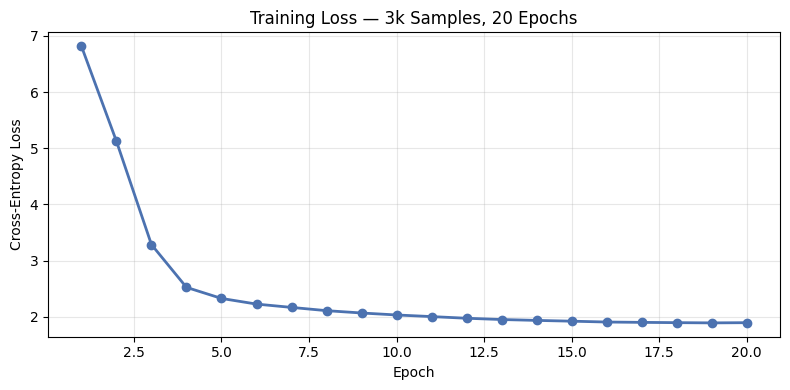

Loss curve saved.


In [ ]:
# Cell 14 — Plot Loss
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(train_losses)+1), train_losses,
         marker="o", color="#4C72B0", linewidth=2)
plt.title("Training Loss — 3k Samples, 20 Epochs")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("Loss curve saved.")

In [ ]:
# Cell 15 — Load Trained Weights
prefix_proj.load_state_dict(torch.load(CKPT_PATH))
prefix_proj.eval()
print("Trained weights loaded.")

Trained weights loaded.


In [ ]:
# Cell 16 — Clean Caption Helper
def clean_caption(text):
    text = text.strip()
    text = text.split("\n")[0].strip()
    text = re.sub(r'\s+', ' ', text)
    return text if len(text.split()) >= 3 else "[no caption]"

In [ ]:
# Cell 17 — CLIP+GPT2 Caption Generator
def generate_caption(img, max_new_tokens=60, beam_width=5):
    prompt        = "a photo of"
    img_emb       = get_image_embedding(img)
    prefix        = prefix_proj(img_emb)
    text_ids      = gpt2_tokenizer(prompt, return_tensors="pt").to(device)["input_ids"]
    text_emb      = gpt2_model.transformer.wte(text_ids)
    inputs_embeds = torch.cat([prefix, text_emb], dim=1)
    attn_mask     = torch.ones(inputs_embeds.shape[:2], dtype=torch.long, device=device)

    with torch.no_grad():
        out = gpt2_model.generate(
            inputs_embeds=inputs_embeds,
            attention_mask=attn_mask,
            max_new_tokens=max_new_tokens,
            min_new_tokens=15,
            num_beams=beam_width,
            early_stopping=False,
            no_repeat_ngram_size=3,
            length_penalty=1.5,
            pad_token_id=gpt2_tokenizer.eos_token_id,
        )
    decoded = gpt2_tokenizer.decode(out[0], skip_special_tokens=True)
    return clean_caption(decoded)

In [ ]:
# Cell 18 — BLIP Caption Generator
def generate_caption_blip(img, beam_width=5, max_new_tokens=50):
    inputs = blip_processor(images=img, return_tensors="pt").to(device)
    with torch.no_grad():
        out = blip_model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            min_new_tokens=8,
            num_beams=beam_width,
            no_repeat_ngram_size=3,
            length_penalty=1.5,
        )
    return blip_processor.decode(out[0], skip_special_tokens=True)


In [ ]:
# Cell 19 — Test Both Models on 10 Training Images
print("=" * 70)
print("BLIP vs CLIP+GPT2 — 10 Image Comparison")
print("=" * 70)

comparison = []
for i in range(10):
    img      = data[i]["image"]
    orig     = data[i]["caption"].split("\n")[0]
    cap_gpt2 = generate_caption(img)
    cap_blip = generate_caption_blip(img)
    comparison.append({"original": orig, "gpt2": cap_gpt2, "blip": cap_blip})
    print(f"\n[{i+1}] Original   : {orig}")
    print(f"     CLIP+GPT2 : {cap_gpt2}")
    print(f"     BLIP      : {cap_blip}")
    print("-" * 70)

with open(f"{M2_DIR}/blip_vs_gpt2.pkl", "wb") as f:
    pickle.dump(comparison, f)
print("\nComparison saved to Drive.")

BLIP vs CLIP+GPT2 — 10 Image Comparison


/usr/local/lib/python3.12/dist-packages/torch/_inductor/compile_fx.py:321: UserWarning: TensorFloat32 tensor cores for float32 matrix multiplication available but not enabled. Consider setting `torch.set_float32_matmul_precision('high')` for better performance.
  warnings.warn(



[1] Original   : The man with pierced ears is wearing glasses and an orange hat.
     CLIP+GPT2 : a man wearing a shirt with the words "I'm a man" in the middle of his face.
     BLIP      : a man wearing a hat and glasses with a cell in his hand
----------------------------------------------------------------------

[2] Original   : A black and white dog is running in a grassy garden surrounded by a white fence.
     CLIP+GPT2 : a dog with a dog collar on its back and a dog leash on its front.
     BLIP      : a dog running in a grassy field with a white picket fence in the background
----------------------------------------------------------------------

[3] Original   : A young female student performing a downward kick to break a board held by her Karate instructor.
     CLIP+GPT2 : a man with a helmet on his head, wearing a helmet and a pair of gloves on his feet.
     BLIP      : a red, blue, and white rug
----------------------------------------------------------------------

[4

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


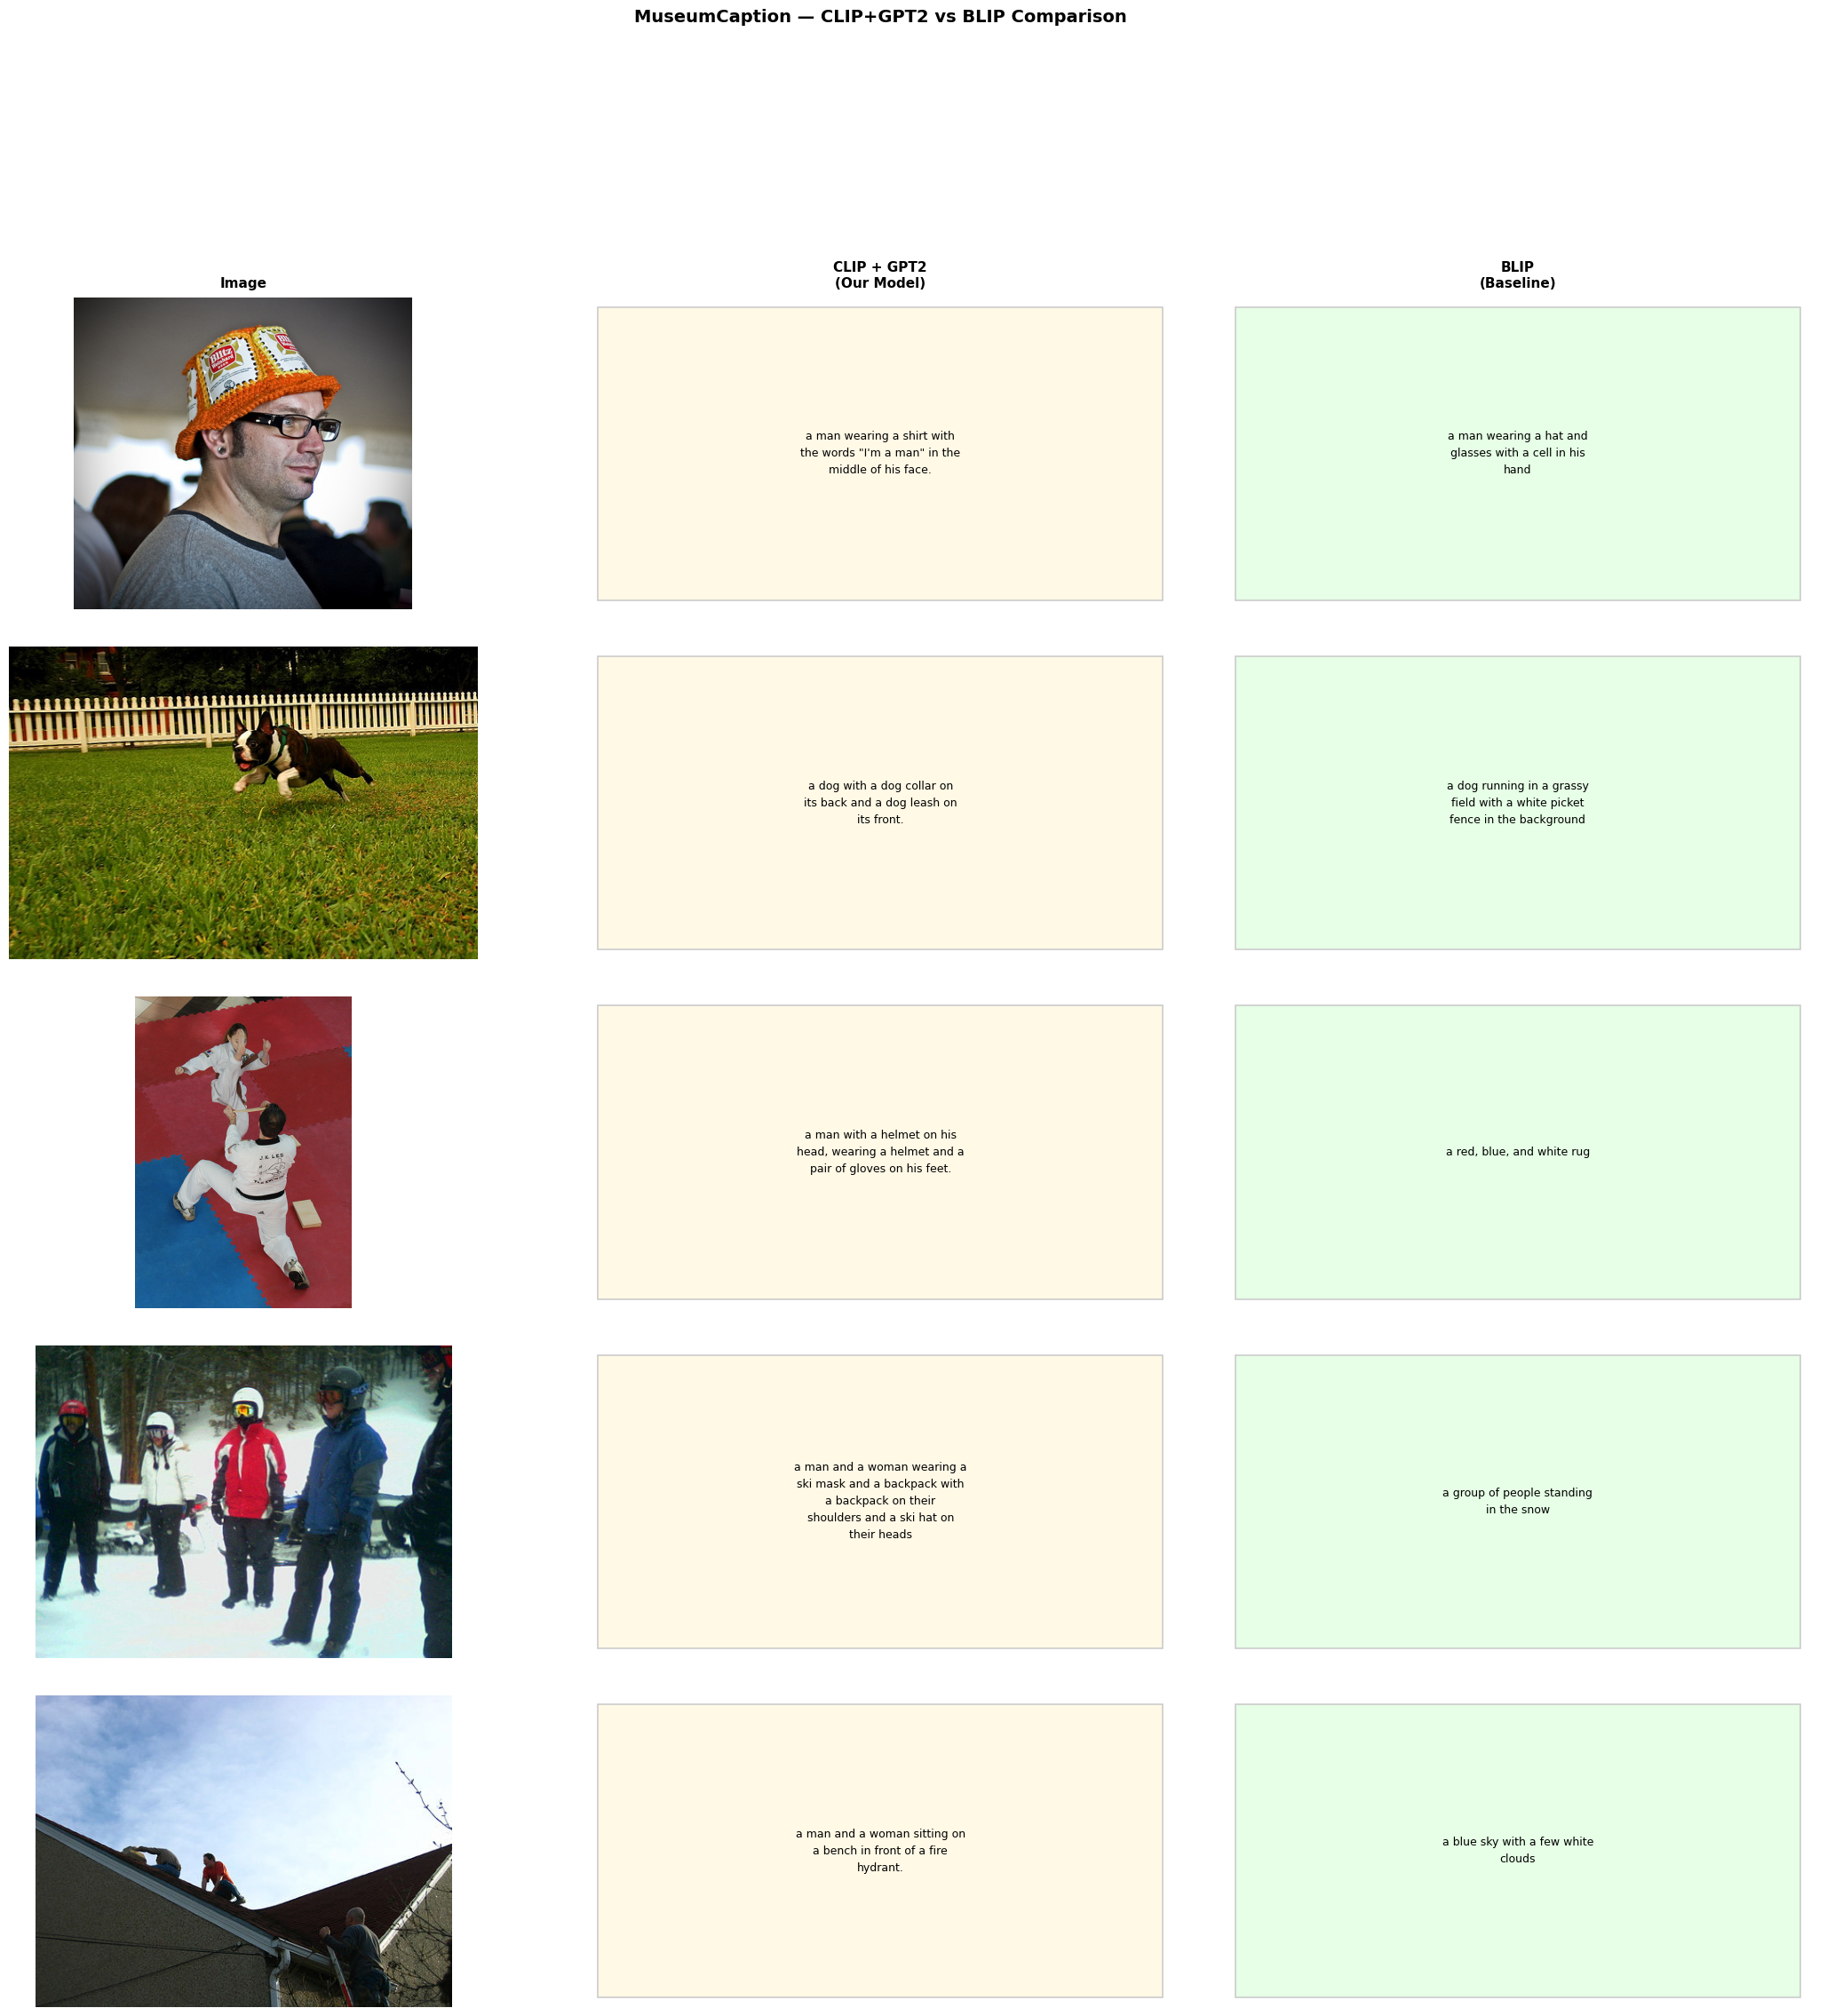

Comparison gallery saved to Drive.


In [ ]:
# Cell 20 — Comparison Gallery (5 images)
import textwrap

fig = plt.figure(figsize=(22, 25))

for i in range(5):
    img      = data[i]["image"]
    cap_gpt2 = comparison[i]["gpt2"]
    cap_blip = comparison[i]["blip"]
    orig     = comparison[i]["original"]

    # Image
    ax_img = fig.add_subplot(5, 3, i * 3 + 1)
    ax_img.imshow(img)
    ax_img.axis("off")
    if i == 0:
        ax_img.set_title("Image", fontsize=11, fontweight="bold", pad=8)

    # CLIP+GPT2
    ax_gpt2 = fig.add_subplot(5, 3, i * 3 + 2)
    ax_gpt2.axis("off")
    ax_gpt2.set_xlim(0, 1)
    ax_gpt2.set_ylim(0, 1)
    ax_gpt2.add_patch(plt.Rectangle((0.03, 0.03), 0.94, 0.94,
                                     facecolor="#fff9e6", edgecolor="#ccc",
                                     linewidth=1.2))
    ax_gpt2.text(0.5, 0.5, "\n".join(textwrap.wrap(cap_gpt2, width=28)),
                 ha="center", va="center", fontsize=9,
                 linespacing=1.6, zorder=5)
    if i == 0:
        ax_gpt2.set_title("CLIP + GPT2\n(Our Model)", fontsize=11,
                           fontweight="bold", pad=8)

    # BLIP
    ax_blip = fig.add_subplot(5, 3, i * 3 + 3)
    ax_blip.axis("off")
    ax_blip.set_xlim(0, 1)
    ax_blip.set_ylim(0, 1)
    ax_blip.add_patch(plt.Rectangle((0.03, 0.03), 0.94, 0.94,
                                     facecolor="#e6ffe6", edgecolor="#ccc",
                                     linewidth=1.2))
    ax_blip.text(0.5, 0.5, "\n".join(textwrap.wrap(cap_blip, width=28)),
                 ha="center", va="center", fontsize=9,
                 linespacing=1.6, zorder=5)
    if i == 0:
        ax_blip.set_title("BLIP\n(Baseline)", fontsize=11,
                           fontweight="bold", pad=8)

plt.suptitle("MuseumCaption — CLIP+GPT2 vs BLIP Comparison",
             fontsize=14, fontweight="bold", y=1.01)
plt.subplots_adjust(left=0.02, right=0.98, wspace=0.06, hspace=0.12)
plt.savefig(f"{M2_DIR}/model_comparison_gallery.png", dpi=150, bbox_inches="tight")
plt.show()
print("Comparison gallery saved to Drive.")

📁 Upload one or more images (jpg/png):


Saving Test 1.jpg to Test 1.jpg

📷 Test 1.jpg
  CLIP+GPT2 : a young girl with a big smile on her face, wearing a pink t-shirt and a pink baseball cap. The girl is wearing a white T-shirt with the words "I love you" written on the front.
  BLIP      : a little girl in a field of flowers - stock image


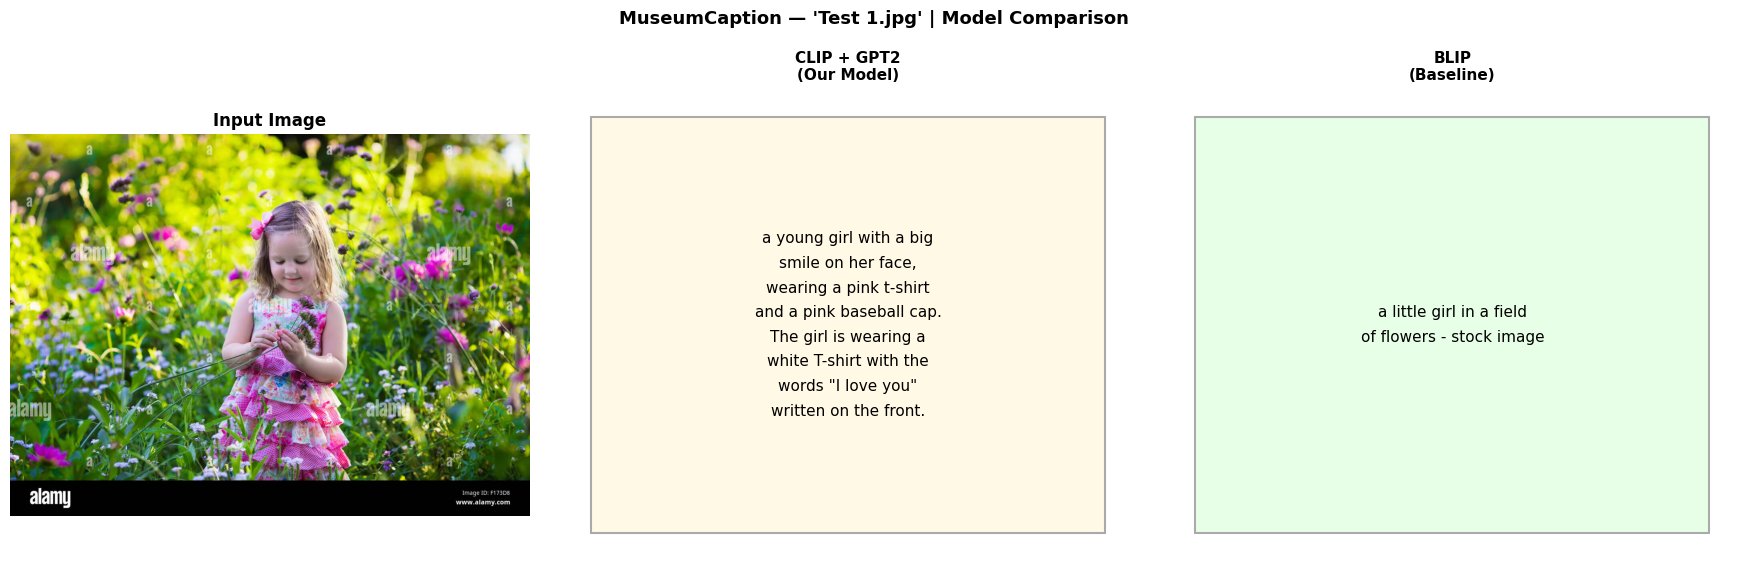

  ✓ Saved: demo_Test_1.png

✓ All 1 results saved to Drive.


In [ ]:
# Cell 21 — Upload Multiple Images → Both Captions, All Saved to Drive
from google.colab import files

print("📁 Upload one or more images (jpg/png):")
uploaded = files.upload()

all_demo_results = []

for img_name, img_bytes in uploaded.items():
    from io import BytesIO
    img      = Image.open(BytesIO(img_bytes)).convert("RGB")
    cap_gpt2 = generate_caption(img)
    cap_blip = generate_caption_blip(img)
    all_demo_results.append({"name": img_name, "gpt2": cap_gpt2, "blip": cap_blip})

    print(f"\n📷 {img_name}")
    print(f"  CLIP+GPT2 : {cap_gpt2}")
    print(f"  BLIP      : {cap_blip}")

    # Save individual figure
    fig, axes = plt.subplots(1, 3, figsize=(18, 6),
                              gridspec_kw={"width_ratios": [1, 1.1, 1.1]})
    axes[0].imshow(img)
    axes[0].set_title("Input Image", fontsize=12, fontweight="bold")
    axes[0].axis("off")

    for ax, cap, title, color in [
        (axes[1], cap_gpt2, "CLIP + GPT2\n(Our Model)", "#fff9e6"),
        (axes[2], cap_blip, "BLIP\n(Baseline)",          "#e6ffe6"),
    ]:
        ax.axis("off")
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.add_patch(plt.Rectangle((0.05, 0.05), 0.9, 0.9,
                                    facecolor=color, edgecolor="#aaa",
                                    linewidth=1.5, transform=ax.transAxes))
        ax.text(0.5, 0.5, "\n".join(textwrap.wrap(cap, width=25)),
                ha="center", va="center", fontsize=11,
                linespacing=1.8, zorder=5, transform=ax.transAxes)
        ax.set_title(title, fontsize=11, fontweight="bold", pad=10)

    plt.suptitle(f"MuseumCaption — '{img_name}' | Model Comparison",
                 fontsize=13, fontweight="bold", y=1.02)
    plt.subplots_adjust(left=0.02, right=0.98, wspace=0.06)

    save_name = img_name.replace(" ", "_").split(".")[0]
    plt.savefig(f"{M2_DIR}/demo_{save_name}.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  ✓ Saved: demo_{save_name}.png")

# Save all results to Drive as pkl
with open(f"{M2_DIR}/all_demo_results.pkl", "wb") as f:
    pickle.dump(all_demo_results, f)
print(f"\n✓ All {len(all_demo_results)} results saved to Drive.")